In [3]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 72.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=7121bfc49b8b4b14abbacd8d170e067942f61ab9aa8e0f78da1193a71119d0a0
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [4]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# Does not require entanglement; it relies on the "no-cloning theorem",
# meaning any eavesdropper trying to intercept the qubits will introduce
# detectable disturbances.

# This notebook is for a simulation of the protocol without an attacker.

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def generate_quantum_random_bit():
    """
    Generates a random bit (0 or 1) using a quantum circuit.

    Creates the state |+> = √½(|0⟩ + |1⟩) and measures it.

    Returns:
        int: A random bit (0 or 1) with equal probability.
    """
    qc = QuantumCircuit(1, 1)  # Create a single-qubit circuit
    qc.h(0)  # Apply Hadamard gate to create superposition (Preparing |+> state)
    qc.measure(0, 0)  # Measure the qubit

    # Execute the circuit on a basic simulator
    simulator = BasicSimulator()
    result = simulator.run(transpile(qc, simulator)).result()
    counts = result.get_counts(qc)
    return int(max(counts, key=counts.get))  # Return the most common outcome

def generate_quantum_random_bits_parallel(n):
    """
    Generate n random bits in parallel using quantum measurements.
    More efficient than generating one at a time.

    Args:
        n (int): Number of random bits to generate

    Returns:
        list: List of n random bits (0s and 1s)
    """
    qc = QuantumCircuit(n, n)

    # Prepare all qubits in |+⟩ state
    for i in range(n):
        qc.h(i)

    # Measure all qubits
    qc.measure(range(n), range(n))

    # Execute the circuit
    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts()

    # Get the bit string (e.g., '01101')
    bitstring = list(counts.keys())[0]

    # Convert to list of integers
    # Note: reversed() because Qiskit orders qubits right-to-left
    return [int(bit) for bit in reversed(bitstring)]

# =============================================================================
# BB84 PROTOCOL FUNCTION
# =============================================================================

def run_bb84_correctly(n_bits=20):

    # ===== ALICE =====
    # Generate random bits and bases
    alice_bits = generate_quantum_random_bits_parallel(n_bits)
    alice_bases = generate_quantum_random_bits_parallel(n_bits)

    # ===== BOB =====
    # Generate random bases (doesn't know Alice's)
    bob_bases = generate_quantum_random_bits_parallel(n_bits)

    # Step 2: For each bit, Alice prepares and sends ONE qubit
    bob_results = []

    for i in range(n_bits):
        # Alice prepares a single qubit (NOT entangled with anything)
        qc = QuantumCircuit(1, 1)

        # Encode bit in chosen basis
        if alice_bits[i] == 1:
            qc.x(0)  # Encode bit value

        if alice_bases[i] == 1:
            qc.h(0)  # Encode in X basis instead of Z basis

        # --- QUANTUM CHANNEL ---
        # This qubit travels from Alice to Bob

        # Bob measures in his chosen basis
        if bob_bases[i] == 1:
            qc.h(0)  # Measure in X basis

        qc.measure(0, 0)

        # Execute
        backend = BasicSimulator()
        compiled = transpile(qc, backend)
        job = backend.run(compiled, shots=1)
        result = job.result()
        counts = result.get_counts()
        bob_results.append(int(list(counts.keys())[0]))

    # ===== RECONCILIATION =====
    # Classical communication - compare bases
    alice_key = []
    bob_key = []

    for i in range(n_bits):
        if alice_bases[i] == bob_bases[i]:  # Same basis?
            alice_key.append(alice_bits[i])
            bob_key.append(bob_results[i])

    print(f"\n{'='*50}")
    print(f"BB84 Protocol Results (No Attacker)")
    print(f"{'='*50}")
    print(f"Sent {n_bits} qubits")
    print(f"Matching bases: {len(alice_key)} (~{len(alice_key)/n_bits*100:.0f}%)")
    print(f"\nAlice's key: {alice_key}")
    print(f"Bob's key:   {bob_key}")

    if len(alice_key) > 0:
        matches = sum([a == b for a, b in zip(alice_key, bob_key)])
        agreement_rate = matches / len(alice_key)
        print(f"\nAgreement rate: {agreement_rate*100:.1f}%")

        if agreement_rate == 1.0:
            print("✓ Perfect key agreement - Protocol successful!")

    return alice_key, bob_key


BB84 Protocol Results (No Attacker)
Sent 20 qubits
Matching bases: 13 (~65%)

Alice's key: [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1]
Bob's key:   [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1]

Agreement rate: 100.0%
✓ Perfect key agreement - Protocol successful!

Quantum Bit Error Rate (QBER): 0.00%

Key Statistics:
Final key has 8 zeros and 5 ones


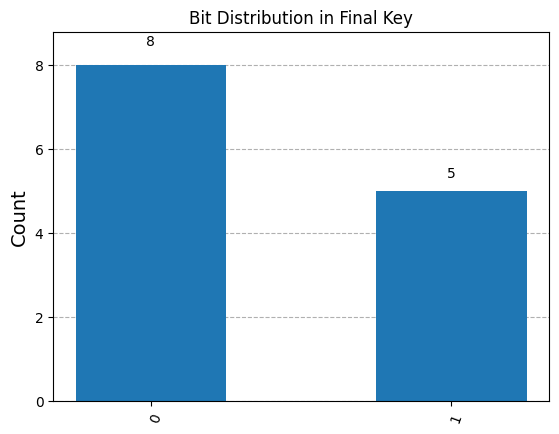

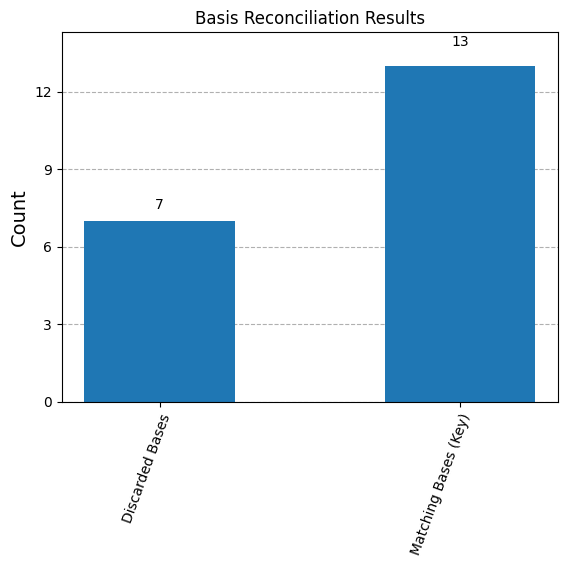

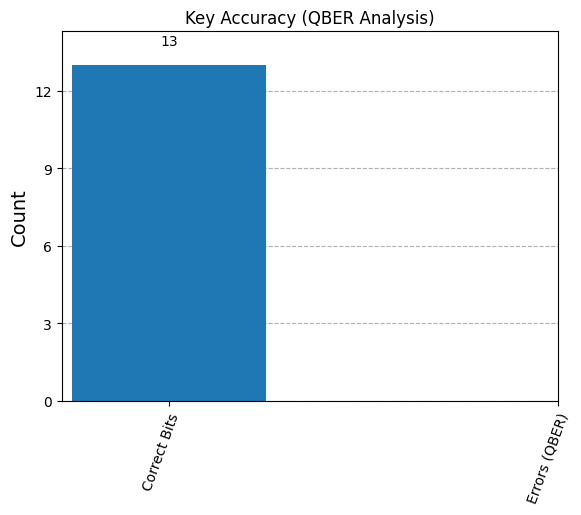

In [10]:
# Test the BB84 protocol (Max qubits is 24 for basic_simulator)
n_bits = 20
alice_key, bob_key = run_bb84_correctly(n_bits=n_bits)

# Calculate Error Rate
errors = sum([1 for a, b in zip(alice_key, bob_key) if a != b])
error_rate = (errors / len(alice_key)) * 100 if alice_key else 0

# Visualize Error Rate vs Success Rate
performance_data = {
    'Correct Bits': len(alice_key) - errors,
    'Errors (QBER)': errors
}

print(f"\nQuantum Bit Error Rate (QBER): {error_rate:.2f}%")

# Show bit distribution in final key
if alice_key:

    zeros = alice_key.count(0)
    ones = alice_key.count(1)

    print(f"\nKey Statistics:")
    print(f"Final key has {zeros} zeros and {ones} ones")

    # Visualize bit distribution
    key_counts = {'0': zeros, '1': ones}
    display(plot_histogram(key_counts, title='Bit Distribution in Final Key'))

# Visualize Reconciliation results (Matches vs Discarded)
matching_bases = len(alice_key)
discarded_bases = n_bits - matching_bases

reconciliation_stats = {
    'Matching Bases (Key)': matching_bases,
    'Discarded Bases': discarded_bases
}

display(plot_histogram(reconciliation_stats, title='Basis Reconciliation Results'))
display(plot_histogram(performance_data, title='Key Accuracy (QBER Analysis)'))